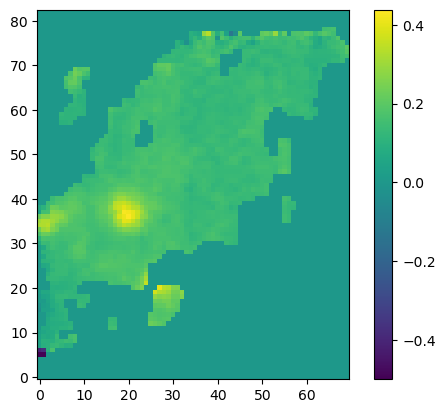

In [ ]:
from q3dfit.q3dout import load_q3dout
from q3dfit import q3dutil
import matplotlib.pyplot as plt
import numpy as np
 
filename_q3di = 'input/q3di_4C1971_neighbour_method.npy'
q3di = q3dutil.get_q3dio(filename_q3di)
 
# col, row = 40, 40
cube, vormap = q3dutil.get_Cube(q3di)
contmap = np.zeros((cube.ncols, cube.nrows), dtype=float)
nspax, colarr, rowarr = q3dutil.get_spaxels(cube)
for ispax in range(0, nspax):
    i = colarr[ispax]
    j = rowarr[ispax]
    try:
        q3do = load_q3dout(q3di, i+1, j+1)
    except FileNotFoundError:
        continue
# q3do = load_q3dout(q3di, col, row)
 
    cont_xy = q3do.cont_fit
    
    contmap[i,j] = np.trapezoid(cont_xy, q3do.wave)

In [43]:
np.unravel_index(np.argmax(contmap), contmap.shape)

(np.int64(20), np.int64(36))

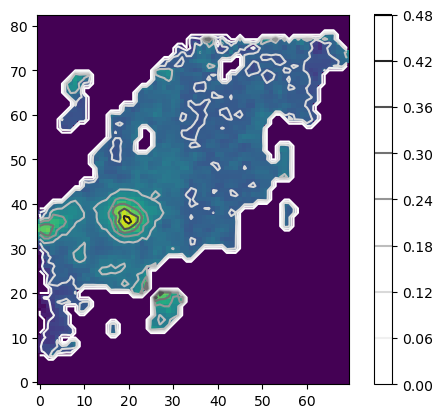

In [52]:
contmap[contmap < 0] = 0
plt.imshow(contmap.T, origin="lower", vmin=0)
plt.contour(contmap.T, cmap="Greys")
plt.colorbar()
np.save("contmap.npy", contmap.T)

In [ ]:
from astropy.io import fits
with fits.open("4C1971_G235H_NRS1_NRS2_s3d.fits") as hdul:
    hdul.info()
    data = hdul[1].data

print(data.shape)

Filename: 4C1971_G235H_NRS1_NRS2_s3d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     374   ()      
  1  SCI           1 ImageHDU        34   (70, 83, 3815)   float64   
  2  SCI           1 ImageHDU        34   (70, 83, 3815)   float64   
  3                1 ImageHDU         8   (70, 83, 3815)   float64   
(3815, 83, 70)


In [26]:
data[2120:2320,:,:].shape

(200, 83, 70)

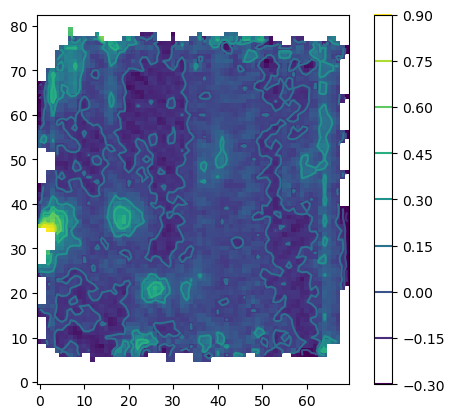

In [48]:
cont_est = np.median(data[2120:2320,:,:], axis=0)
plt.imshow(cont_est, origin="lower", vmin=0)
plt.contour(cont_est)
plt.colorbar()

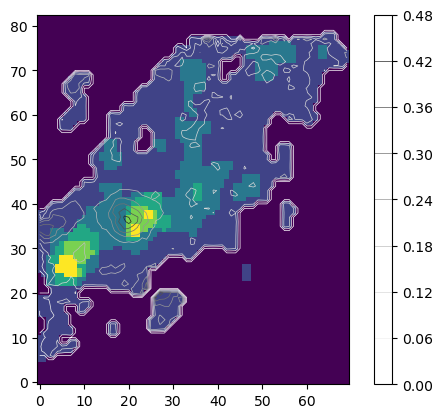

In [56]:
rmf = np.load("smoothed_rmf_map.npy")
plt.imshow(rmf.T, origin="lower")
plt.contour(contmap.T, cmap="Greys", linewidths=0.5)
plt.colorbar()

(3815, 83, 70)
[1.66019797 1.66059397 1.66098997 ... 3.16974992 3.17014592 3.17054192]


/tmp/ipykernel_21064/3397872962.py:53: RuntimeWarning: All-NaN slice encountered
  continuum_map = np.nanmedian(continuum_cube, axis=0)
/tmp/ipykernel_21064/3397872962.py:57: RuntimeWarning: invalid value encountered in power
  contour_continuum_map = np.where(continuum_map<0.7, continuum_map, np.nan)**0.8


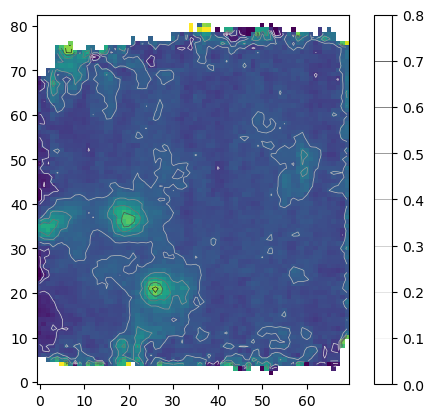

In [98]:
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt

# Load JWST NIRSpec IFU cube
filename = "4C1971_G235H_NRS1_NRS2_s3d.fits"
hdul = fits.open(filename)

# Typically science data is in extension 1
data = hdul[1].data  # shape: (lambda, y, x)
header = hdul[1].header
print(data.shape)

# Build WCS to get wavelength axis
wcs = WCS(header)

# Extract wavelength array (in microns)
# JWST cubes usually use axis 3 as wavelength
n_lambda = data.shape[0]
pixel_indices = np.arange(n_lambda)

# Build pixel grid correctly: (x, y, z)
x = np.zeros(n_lambda)
y = np.zeros(n_lambda)
z = np.arange(n_lambda)

world = wcs.all_pix2world(x, y, z, 0)

# Spectral axis is usually the 3rd output
wavelength = world[2]

print(wavelength)
# --------------------------------------------------
# Define continuum wavelength ranges (example!)
# You MUST adjust these depending on your target
# --------------------------------------------------
continuum_ranges = [
    (2.17, 2.22),
    (2.32, 2.37)
]

# Create mask for continuum regions
mask = np.zeros_like(wavelength, dtype=bool)
for wmin, wmax in continuum_ranges:
    mask |= (wavelength >= wmin) & (wavelength <= wmax)

# Select continuum slices
continuum_cube = data[mask, :, :]

# Collapse spectral axis → continuum map
# Use median for robustness against residual lines
continuum_map = np.nanmedian(continuum_cube, axis=0)

# levels = np.nanpercentile(continuum_map, (70, 80, 90, 95, 98, 99, 99.5))
# continuum_map = np.where((continuum_map>levels.min()) & (continuum_map<levels.max()), continuum_map, np.nan)
contour_continuum_map = np.where(continuum_map<0.7, continuum_map, np.nan)**0.8

plt.imshow(continuum_map, origin="lower", vmin=0, vmax=0.8)
plt.contour(contour_continuum_map, cmap="Greys", linewidths=0.5)#, levels=levels)
plt.colorbar()
np.save("contmap.npy", contour_continuum_map)

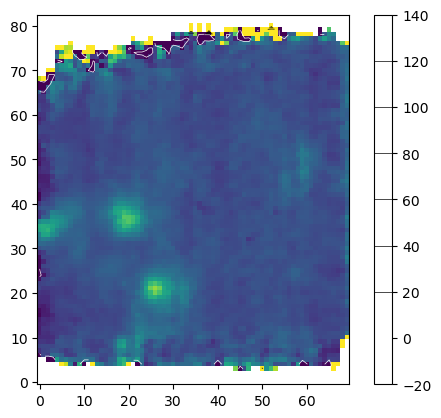

In [104]:
from numpy.polynomial.polynomial import polyfit, polyval

continuum_map = np.zeros(data.shape[1:])

for y in range(data.shape[1]):
    for x in range(data.shape[2]):
        spectrum = data[:, y, x]

        # Apply continuum mask
        w = wavelength[mask]
        s = spectrum[mask]

        # Remove NaNs
        valid = np.isfinite(s)
        if np.sum(valid) < 5:
            continuum_map[y, x] = np.nan
            continue

        # Fit linear continuum
        coeffs = polyfit(w[valid], s[valid], deg=1)

        # Evaluate continuum at central wavelength
        continuum_map[y, x] = polyval(np.median(w), coeffs)

plt.imshow(continuum_map, origin="lower", vmin=0, vmax=0.8)
plt.contour(continuum_map, cmap="Greys", linewidths=0.5, vmin=0, vmax=0.8)
plt.colorbar()